# Cube Surface Width And Msat Fit

This notebook fits two surface-layer parameters from a tilted magnetic phase target:

1. surface width per face, with a fixed outer cube edge;
2. surface-layer saturation magnetization `Msat`.

The first target is synthetic NeuralMag truth. A hard shell generates the truth, a steep sigmoid shell is validated against it, and the fit uses the differentiable soft shell. A vmapped grid search maps the initial loss plane before Adam refinement.


In [1]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.85")

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import jax.scipy.ndimage as jsnd
import matplotlib.pyplot as plt
import numpy as np
import optax
import unxt as u

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for path in (repo_root / "src", repo_root / "vendor" / "neuralmag"):
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

import neuralmag as nm
from libertem_holo.base.mbir import MU_0, build_rdfc_kernel
from libertem_holo.base.mbir.kernel import phase_mapper_rdfc

nm.config.dtype = "float64"
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {getattr(nm.config.backend, 'name', nm.config.backend)}")


2026-04-30 08:37:13 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-30 08:37:14 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-30 08:37:14 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


## Parameters


In [2]:
# Geometry and synthetic truth.
outer_edge_length_nm = 80.0
cell_size_nm = 1.0
truth_surface_width_nm = 5.0
truth_surface_msat_a_per_m = 100e3
random_seed = 21

# Fixed material parameters.
core_msat_a_per_m = 480e3
core_kc_j_per_m3 = -1.3e4
aex_j_per_m = 1e-11
demag_p = 3

# Soft shell used by the differentiable fit.
shell_softness_nm = 0.15
soft_shell_min_agreement = 0.99
soft_shell_max_volume_error = 0.01

# Truth relaxation controls.
truth_minimise_tol = 1e2
truth_minimise_max_iter = 50_000
truth_tau_min = 1e-18
truth_tau_max = 1e-4

# Inner differentiable BB/Cayley relaxation controls.
fit_inner_steps = 1000
fit_inner_tol = 1e2
fit_dynamic_max_iter = 50_000
fit_tau_min = 1e-18
fit_tau_max = 1e-4

# Tilted target phase.
phase_padding_px = 32
tilt_rotation_deg = 45.0
tilt_deg = 45.0
target_crop_margin_px = 8

# Initial loss-plane grid search.
width_bounds_nm = (0.0, 15.0)
surface_msat_bounds_a_per_m = (50e3, 480e3)
width_grid_n = 31
msat_grid_n = 31
grid_batch_size = 32

# Adam refinement.
outer_steps = 300
outer_learning_rate = 0.05
adam_log_every = 10

n = int(round(outer_edge_length_nm / cell_size_nm))
if not np.isclose(n * cell_size_nm, outer_edge_length_nm):
    raise ValueError("outer_edge_length_nm must be an integer multiple of cell_size_nm.")
if truth_surface_width_nm < 0.0 or 2.0 * truth_surface_width_nm >= outer_edge_length_nm:
    raise ValueError("truth_surface_width_nm must be non-negative and less than half the outer edge.")
if width_bounds_nm[0] < 0.0 or 2.0 * width_bounds_nm[1] >= outer_edge_length_nm:
    raise ValueError("width_bounds_nm must stay inside the fixed outer cube.")

shape_xyz = (n, n, n)
mesh_step_m = (cell_size_nm * 1e-9,) * 3
solver_dtype = jnp.float64
mu0 = jnp.asarray(MU_0.value, dtype=solver_dtype)
rotation_rad = np.deg2rad(tilt_rotation_deg)
tilt_rad = np.deg2rad(tilt_deg)

print(f"Outer cube: {outer_edge_length_nm:g} nm = {n} cells")
print(f"Truth shell: {truth_surface_width_nm:g} nm per face, Ms={truth_surface_msat_a_per_m / 1e3:g} kA/m")
print(f"Fit width bounds: {width_bounds_nm[0]:g}-{width_bounds_nm[1]:g} nm")
print(f"Fit Msat bounds: {surface_msat_bounds_a_per_m[0] / 1e3:g}-{surface_msat_bounds_a_per_m[1] / 1e3:g} kA/m")


Outer cube: 80 nm = 80 cells
Truth shell: 5 nm per face, Ms=100 kA/m
Fit width bounds: 0-15 nm
Fit Msat bounds: 50-480 kA/m


## Geometry And Material Helpers


In [3]:
def cell_centers_np(shape_xyz, spacing_nm):
    axes = [
        (np.arange(size, dtype=np.float64) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape_xyz
    ]
    return np.meshgrid(*axes, indexing="ij")


def cell_centers_jax(shape_xyz, spacing_nm, dtype=solver_dtype):
    axes = [
        (jnp.arange(size, dtype=dtype) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape_xyz
    ]
    return jnp.meshgrid(*axes, indexing="ij")


xx_np, yy_np, zz_np = cell_centers_np(shape_xyz, cell_size_nm)
max_abs_np = np.maximum.reduce([np.abs(xx_np), np.abs(yy_np), np.abs(zz_np)])
xx_jax, yy_jax, zz_jax = cell_centers_jax(shape_xyz, cell_size_nm)
max_abs_jax = jnp.maximum(jnp.maximum(jnp.abs(xx_jax), jnp.abs(yy_jax)), jnp.abs(zz_jax))


def hard_shell_weights(surface_width_nm):
    inner_half_nm = outer_edge_length_nm / 2.0 - float(surface_width_nm)
    core = (max_abs_np <= inner_half_nm).astype(np.float64)
    surface = 1.0 - core
    return core, surface


def soft_shell_weights(surface_width_nm, softness_nm=shell_softness_nm):
    width = jnp.asarray(surface_width_nm, dtype=solver_dtype)
    inner_half_nm = outer_edge_length_nm / 2.0 - width
    signed_margin_nm = inner_half_nm - max_abs_jax
    core = jax.nn.sigmoid(signed_margin_nm / float(softness_nm))
    surface = 1.0 - core
    return core, surface


def material_fields_from_weights(core_weight, surface_weight, surface_msat_a_per_m):
    surface_msat = jnp.asarray(surface_msat_a_per_m, dtype=solver_dtype)
    ms = core_weight * core_msat_a_per_m + surface_weight * surface_msat
    kc = core_weight * core_kc_j_per_m3
    return ms.astype(solver_dtype), kc.astype(solver_dtype)


def hard_material_fields(surface_width_nm, surface_msat_a_per_m):
    core_weight, surface_weight = hard_shell_weights(surface_width_nm)
    ms = core_weight * core_msat_a_per_m + surface_weight * float(surface_msat_a_per_m)
    kc = core_weight * core_kc_j_per_m3
    return core_weight, surface_weight, ms.astype(np.float64), kc.astype(np.float64)


def normalize_np(values):
    values = np.asarray(values, dtype=np.float64)
    norm = np.linalg.norm(values, axis=-1, keepdims=True)
    return values / np.where(norm > 0.0, norm, 1.0)


def normalize_jax(values):
    norm = jnp.linalg.norm(values, axis=-1, keepdims=True)
    return values / jnp.maximum(norm, jnp.finfo(values.dtype).eps)


def initial_magnetization(surface_width_nm, seed):
    core_weight, surface_weight = hard_shell_weights(surface_width_nm)
    phi = np.arctan2(yy_np, xx_np)

    vortex = np.zeros(shape_xyz + (3,), dtype=np.float64)
    vortex[..., 0] = -np.sin(phi)
    vortex[..., 1] = np.cos(phi)
    vortex[..., 2] = 0.15 * np.tanh(zz_np / (0.2 * outer_edge_length_nm))
    vortex = normalize_np(vortex)

    rng = np.random.default_rng(seed)
    random_surface = normalize_np(rng.normal(size=vortex.shape))
    return normalize_np(core_weight[..., None] * vortex + surface_weight[..., None] * random_surface)


def xyz_to_zyx(values):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return np.transpose(np.asarray(values), axes)


def xyz_to_zyx_jax(values):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return jnp.transpose(values, axes)


def pad_xyz_jax(values, pad_px):
    if pad_px <= 0:
        return values
    pad_width = ((pad_px, pad_px), (pad_px, pad_px), (pad_px, pad_px))
    if values.ndim == 4:
        pad_width = pad_width + ((0, 0),)
    return jnp.pad(values, pad_width)


## Soft Shell Verification


Mask agreement: 100.000%
Core volume error: 0.000%
Surface volume error: 0.000%


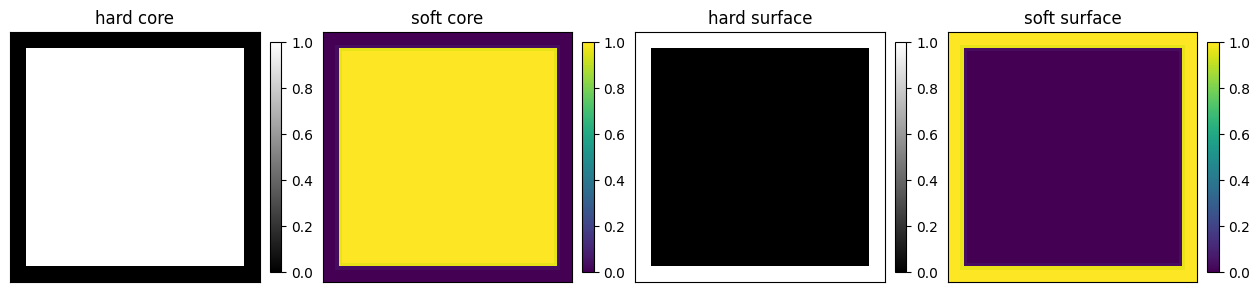

In [4]:
hard_core, hard_surface = hard_shell_weights(truth_surface_width_nm)
soft_core = np.asarray(jax.device_get(soft_shell_weights(truth_surface_width_nm)[0]))
soft_core_binary = soft_core > 0.5
hard_core_binary = hard_core > 0.5

mask_agreement = float(np.mean(soft_core_binary == hard_core_binary))
hard_core_volume = float(hard_core.sum())
soft_core_volume = float(soft_core_binary.sum())
core_volume_error = abs(soft_core_volume - hard_core_volume) / max(hard_core_volume, 1.0)
hard_surface_volume = float(hard_surface.sum())
soft_surface_volume = float((~soft_core_binary).sum())
surface_volume_error = abs(soft_surface_volume - hard_surface_volume) / max(hard_surface_volume, 1.0)

print(f"Mask agreement: {100.0 * mask_agreement:.3f}%")
print(f"Core volume error: {100.0 * core_volume_error:.3f}%")
print(f"Surface volume error: {100.0 * surface_volume_error:.3f}%")
if mask_agreement < soft_shell_min_agreement or max(core_volume_error, surface_volume_error) > soft_shell_max_volume_error:
    print("WARNING: soft shell does not match the hard shell closely enough; reduce shell_softness_nm before trusting the fit.")

mid = n // 2
fig, axs = plt.subplots(1, 4, figsize=(12.5, 3.0), constrained_layout=True)
for ax, image, title, vmin, vmax, cmap in [
    (axs[0], hard_core[:, :, mid].T, "hard core", 0, 1, "gray"),
    (axs[1], soft_core[:, :, mid].T, "soft core", 0, 1, "viridis"),
    (axs[2], hard_surface[:, :, mid].T, "hard surface", 0, 1, "gray"),
    (axs[3], (1.0 - soft_core[:, :, mid]).T, "soft surface", 0, 1, "viridis"),
]:
    im = ax.imshow(image, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## NeuralMag State And Phase Helpers


In [5]:
def constant_vector_cell_function(state, vector_xyz):
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_vectors_to_node_function(state, values_xyz):
    cell = nm.VectorCellFunction(state, tensor=state.tensor(values_xyz, dtype=state.dtype))
    node = np.asarray(cell.to_node().tensor)
    return nm.VectorFunction(state, tensor=state.tensor(normalize_np(node), dtype=state.dtype))


def build_cube_state(m_cell, ms_field, kc_field):
    state = nm.State(nm.Mesh(shape_xyz, mesh_step_m))
    state.t = state.tensor(0.0)
    state.rho = nm.CellFunction(state).fill(1.0)
    state.material.Ms = nm.CellFunction(state, tensor=state.tensor(np.asarray(ms_field, dtype=np.float64), dtype=state.dtype))
    state.material.A = nm.CellFunction(state).fill(aex_j_per_m)
    state.material.Kc = nm.CellFunction(state, tensor=state.tensor(np.asarray(kc_field, dtype=np.float64), dtype=state.dtype))

    axis_111 = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    axis_111 /= np.linalg.norm(axis_111)
    axis_1m10 = np.array([1.0, -1.0, 0.0], dtype=np.float64)
    axis_1m10 -= np.dot(axis_1m10, axis_111) * axis_111
    axis_1m10 /= np.linalg.norm(axis_1m10)
    axis_11m2 = np.cross(axis_111, axis_1m10)

    state.material.Kc_axis1 = constant_vector_cell_function(state, axis_111)
    state.material.Kc_axis2 = constant_vector_cell_function(state, axis_1m10)
    state.material.Kc_axis3 = constant_vector_cell_function(state, axis_11m2)
    state.m = cell_vectors_to_node_function(state, m_cell)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


def unit_node_projection(m_node):
    return normalize_jax(m_node)


def dynamic_minimizer_kwargs(tol, max_iter):
    return dict(
        method="alternating",
        update="cayley",
        projection=unit_node_projection,
        tau_min=truth_tau_min,
        tau_max=truth_tau_max,
        tol=tol,
        max_iter=max_iter,
    )


def cell_from_state(state):
    return normalize_np(np.asarray(state.m.to_cell().tensor))


def _rotation_matrix_z_np(angle):
    c = np.cos(float(angle))
    s = np.sin(float(angle))
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float64)


def _rotation_matrix_x_np(angle):
    c = np.cos(float(angle))
    s = np.sin(float(angle))
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]], dtype=np.float64)


def tilt_rotation_matrix_np(rotation, tilt):
    return _rotation_matrix_z_np(-rotation) @ _rotation_matrix_x_np(tilt) @ _rotation_matrix_z_np(rotation)


def tilted_projection_geometry(dim_zyx, rotation, tilt, dim_uv=None):
    dim_z, dim_y, dim_x = (int(v) for v in dim_zyx)
    rot = tilt_rotation_matrix_np(rotation, tilt)

    half_extents = np.array([dim_x, dim_y, dim_z], dtype=np.float64) / 2.0
    corners = np.array(np.meshgrid([-1.0, 1.0], [-1.0, 1.0], [-1.0, 1.0], indexing="ij")).reshape(3, -1).T
    rotated = (corners * half_extents) @ rot.T
    span_u = rotated[:, 0].max() - rotated[:, 0].min()
    span_v = rotated[:, 1].max() - rotated[:, 1].min()
    span_t = rotated[:, 2].max() - rotated[:, 2].min()

    if dim_uv is None:
        dim_uv = (max(1, int(np.ceil(span_v))), max(1, int(np.ceil(span_u))))
    dim_t = max(1, int(np.ceil(span_t)))

    dim_v, dim_u = (int(v) for v in dim_uv)
    t = np.arange(dim_t, dtype=np.float64) + 0.5 - dim_t / 2.0
    v = np.arange(dim_v, dtype=np.float64) + 0.5 - dim_v / 2.0
    u_axis = np.arange(dim_u, dtype=np.float64) + 0.5 - dim_u / 2.0
    tt, vv, uu = np.meshgrid(t, v, u_axis, indexing="ij")
    detector_xyz = np.stack([uu, vv, tt], axis=0).reshape(3, -1)
    volume_xyz = rot.T @ detector_xyz

    x_idx = volume_xyz[0] + dim_x / 2.0 - 0.5
    y_idx = volume_xyz[1] + dim_y / 2.0 - 0.5
    z_idx = volume_xyz[2] + dim_z / 2.0 - 0.5
    coords_zyx = np.stack([z_idx, y_idx, x_idx], axis=0)
    return {
        "dim_uv": (dim_v, dim_u),
        "dim_t": dim_t,
        "coords_zyx": jnp.asarray(coords_zyx, dtype=solver_dtype),
        "coeff": jnp.asarray(rot[:2, :], dtype=solver_dtype),
    }


padded_dim_zyx = (n + 2 * phase_padding_px, n + 2 * phase_padding_px, n + 2 * phase_padding_px)
tilted_geometry = tilted_projection_geometry(padded_dim_zyx, rotation_rad, tilt_rad)
tilted_dim_uv = tilted_geometry["dim_uv"]
tilted_rdfc_kernel = build_rdfc_kernel(tilted_dim_uv, geometry="disc", dtype=solver_dtype)


def tilted_project_jax(volume_zyx):
    components_first = jnp.moveaxis(volume_zyx, -1, 0)
    out_shape = (tilted_geometry["dim_t"], tilted_dim_uv[0], tilted_dim_uv[1])

    def sample_component(field):
        sampled = jsnd.map_coordinates(
            field,
            tilted_geometry["coords_zyx"],
            order=1,
            mode="constant",
            cval=0.0,
        )
        return sampled.reshape(out_shape)

    sampled = jax.vmap(sample_component, in_axes=0, out_axes=0)(components_first)
    summed = jnp.sum(jnp.moveaxis(sampled, 0, -1), axis=0)
    return jnp.einsum("...c,oc->...o", summed, tilted_geometry["coeff"])


def tilted_phase_from_induction_jax(induction_zyx):
    projected = tilted_project_jax(induction_zyx)
    phase_density = (float(cell_size_nm) ** 2) * phase_mapper_rdfc(
        projected[..., 0],
        projected[..., 1],
        tilted_rdfc_kernel,
    )
    return phase_density


def phase_from_cell_jax(m_cell_xyz, ms_field_xyz):
    m_cell_xyz = normalize_jax(m_cell_xyz)
    induction_xyz = m_cell_xyz * (mu0 * ms_field_xyz[..., None])
    induction_zyx = xyz_to_zyx_jax(pad_xyz_jax(induction_xyz, phase_padding_px))
    return tilted_phase_from_induction_jax(induction_zyx)


def support_mask_for_tilted_projection():
    support_xyz = jnp.ones(shape_xyz, dtype=solver_dtype)
    support_zyx = xyz_to_zyx_jax(pad_xyz_jax(support_xyz, phase_padding_px))
    support_vec_zyx = jnp.repeat(support_zyx[..., None], 3, axis=-1)
    projected = tilted_project_jax(support_vec_zyx)
    return np.linalg.norm(np.asarray(jax.device_get(projected)), axis=-1) > 1e-8


def crop_from_mask(mask_yx, margin_px=target_crop_margin_px):
    ys, xs = np.where(mask_yx)
    if ys.size == 0 or xs.size == 0:
        raise ValueError("Cannot crop an empty support mask.")
    y0 = max(int(ys.min()) - int(margin_px), 0)
    y1 = min(int(ys.max()) + int(margin_px) + 1, mask_yx.shape[0])
    x0 = max(int(xs.min()) - int(margin_px), 0)
    x1 = min(int(xs.max()) + int(margin_px) + 1, mask_yx.shape[1])
    return slice(y0, y1), slice(x0, x1)


def mean_subtracted_rms(prediction, target):
    prediction = prediction - jnp.mean(prediction)
    target = target - jnp.mean(target)
    residual = prediction - target
    return jnp.sqrt(jnp.mean(residual * residual))

print(f"Tilted detector shape: {tilted_dim_uv}, beam samples: {tilted_geometry['dim_t']}")


Tilted detector shape: (216, 216), beam samples: 246


## Synthetic Truth Target


In [6]:
truth_core, truth_surface, truth_ms_field, truth_kc_field = hard_material_fields(
    truth_surface_width_nm,
    truth_surface_msat_a_per_m,
)
m0_cell = initial_magnetization(truth_surface_width_nm, random_seed)
truth_state = build_cube_state(m0_cell, truth_ms_field, truth_kc_field)

started = time.perf_counter()
truth_converged, truth_info = nm.minimise(
    truth_state,
    **dynamic_minimizer_kwargs(truth_minimise_tol, truth_minimise_max_iter),
    return_info=True,
)
truth_elapsed_s = time.perf_counter() - started
truth_m_cell = cell_from_state(truth_state)

support_mask_yx = support_mask_for_tilted_projection()
target_crop_y, target_crop_x = crop_from_mask(support_mask_yx)
target_phase_yx = np.asarray(jax.device_get(phase_from_cell_jax(
    jnp.asarray(truth_m_cell, dtype=solver_dtype),
    jnp.asarray(truth_ms_field, dtype=solver_dtype),
)), dtype=np.float64)
target_phase_crop = target_phase_yx[target_crop_y, target_crop_x]
tilted_dim_uv = tuple(int(v) for v in target_phase_yx.shape)
tilted_rdfc_kernel = build_rdfc_kernel(tilted_dim_uv, geometry="disc", dtype=solver_dtype)
target_phase_crop_jax = jnp.asarray(target_phase_crop, dtype=solver_dtype)

print(f"Truth converged: {truth_converged}")
print(f"Truth iterations: {int(np.asarray(truth_info['n_iter'])):,}")
print(f"Truth max_g: {float(np.asarray(truth_info['max_g'])):.3g}")
print(f"Truth energy: {float(np.asarray(truth_state.E)):.6e} J")
print(f"Truth relaxation elapsed: {truth_elapsed_s:.2f} s")
print(f"Target phase shape: {target_phase_yx.shape}, crop shape: {target_phase_crop.shape}")


2026-04-30 08:37:16 NeuralMag:INFO [Mesh] 3D, 80 x 80 x 80 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-30 08:37:16 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-30 08:37:16 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-30 08:37:16 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-30 08:37:16 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-30 08:37:16 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-30 08:37:20 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-30 08:37:20 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-30 08:37:25 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energy E = 3.67483e-15 J
2

Truth converged: True
Truth iterations: 5,542
Truth max_g: 91.4
Truth energy: 1.439815e-17 J
Truth relaxation elapsed: 54.72 s
Target phase shape: (216, 216), crop shape: (136, 136)


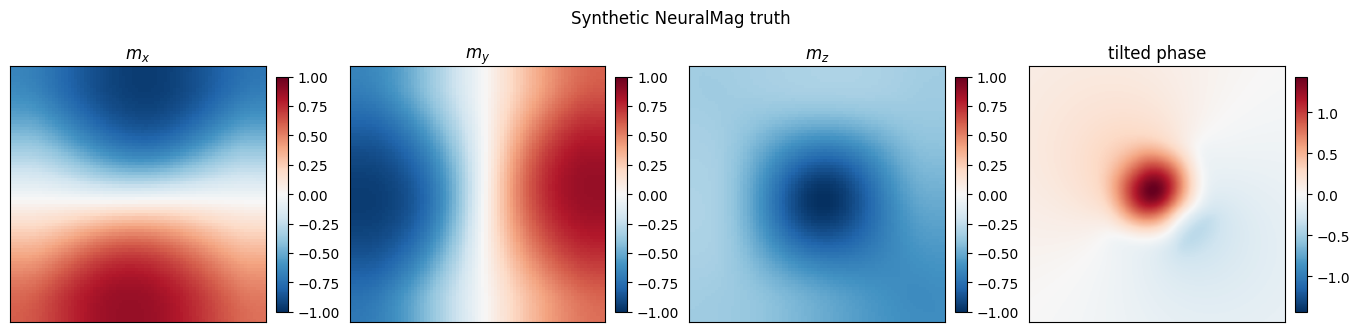

In [7]:
def plot_m_components_and_phase(m_cell, phase_yx, title):
    m_cell = normalize_np(m_cell)
    mid = m_cell.shape[2] // 2
    phase_lim = max(float(np.max(np.abs(phase_yx))), 1e-12)
    panels = [
        (m_cell[:, :, mid, 0].T, "$m_x$", -1.0, 1.0),
        (m_cell[:, :, mid, 1].T, "$m_y$", -1.0, 1.0),
        (m_cell[:, :, mid, 2].T, "$m_z$", -1.0, 1.0),
        (phase_yx, "tilted phase", -phase_lim, phase_lim),
    ]
    fig, axs = plt.subplots(1, 4, figsize=(13.5, 3.5), constrained_layout=True)
    for ax, (image, title_text, vmin, vmax) in zip(axs, panels):
        im = ax.imshow(image, cmap="RdBu_r", vmin=vmin, vmax=vmax)
        ax.set_title(title_text)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


plot_m_components_and_phase(truth_m_cell, target_phase_yx, "Synthetic NeuralMag truth")


## Differentiable Fit Setup


In [8]:
template_ms = np.full(shape_xyz, core_msat_a_per_m, dtype=np.float64)
template_kc = np.full(shape_xyz, core_kc_j_per_m3, dtype=np.float64)
fit_state = build_cube_state(m0_cell, template_ms, template_kc)
fit_minimizer = nm.EnergyMinimizer(
    fit_state,
    method="alternating",
    update="cayley",
    projection=unit_node_projection,
    tau_min=fit_tau_min,
    tau_max=fit_tau_max,
    tol=fit_inner_tol,
    max_iter=fit_inner_steps,
    parameters=["material__Ms", "material__Kc"],
)
input_m_node = jnp.asarray(fit_state.m.tensor, dtype=solver_dtype)
node_to_cell = fit_state.resolve(fit_state.m._code.to_cell, ["f"])


def cell_from_node_jax(m_node):
    return normalize_jax(node_to_cell(normalize_jax(m_node)))


def fit_material_fields(surface_width_nm, surface_msat_a_per_m):
    core_weight, surface_weight = soft_shell_weights(surface_width_nm)
    return material_fields_from_weights(core_weight, surface_weight, surface_msat_a_per_m)


def predict_phase_crop(surface_width_nm, surface_msat_a_per_m, *, fixed_steps=fit_inner_steps, checkpoint=True):
    ms_field, kc_field = fit_material_fields(surface_width_nm, surface_msat_a_per_m)
    m_final_node = fit_minimizer.solve_fixed(
        input_m_node,
        ms_field,
        kc_field,
        steps=int(fixed_steps),
        checkpoint=checkpoint,
    )
    m_final_cell = cell_from_node_jax(m_final_node)
    phase_yx = phase_from_cell_jax(
        m_final_cell,
        ms_field,
    )
    return phase_yx[target_crop_y, target_crop_x], m_final_cell


def loss_from_values(surface_width_nm, surface_msat_a_per_m):
    # Grid scouting does not need reverse-mode rematerialization. Keeping
    # checkpoint=False makes vmapped compilation much lighter.
    phase_crop, _ = predict_phase_crop(surface_width_nm, surface_msat_a_per_m, checkpoint=False)
    return mean_subtracted_rms(phase_crop, target_phase_crop_jax)


@jax.jit
def loss_from_values_jit(surface_width_nm, surface_msat_a_per_m):
    return loss_from_values(surface_width_nm, surface_msat_a_per_m)


@jax.jit
def loss_batch(width_batch_nm, msat_batch_a_per_m):
    return jax.vmap(loss_from_values)(width_batch_nm, msat_batch_a_per_m)


def bounded_value(theta, bounds):
    lo, hi = bounds
    return lo + (hi - lo) * jax.nn.sigmoid(theta)


def inverse_bounded_value(value, bounds):
    lo, hi = bounds
    frac = np.clip((float(value) - lo) / (hi - lo), 1e-12, 1.0 - 1e-12)
    return np.log(frac / (1.0 - frac))


def unpack_theta(theta):
    width_nm = bounded_value(theta[0], width_bounds_nm)
    surface_msat = bounded_value(theta[1], surface_msat_bounds_a_per_m)
    return width_nm, surface_msat


def loss_with_aux(theta):
    width_nm, surface_msat = unpack_theta(theta)
    phase_crop, m_final_cell = predict_phase_crop(width_nm, surface_msat, checkpoint=True)
    rms = mean_subtracted_rms(phase_crop, target_phase_crop_jax)
    return rms, {
        "width_nm": width_nm,
        "surface_msat_a_per_m": surface_msat,
        "phase_crop": phase_crop,
        "m_final_cell": m_final_cell,
    }


loss_grad_aux = jax.jit(jax.value_and_grad(loss_with_aux, has_aux=True))
loss_with_aux_jit = jax.jit(loss_with_aux)

print("Fit machinery ready.")


2026-04-30 08:38:17 NeuralMag:INFO [Mesh] 3D, 80 x 80 x 80 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-30 08:38:17 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-30 08:38:17 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-30 08:38:17 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-30 08:38:17 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-30 08:38:17 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-30 08:38:19 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-30 08:38:19 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


Fit machinery ready.


## VMapped Loss-Plane Grid Search


In [9]:
width_grid_nm = np.linspace(width_bounds_nm[0], width_bounds_nm[1], int(width_grid_n), dtype=np.float64)
msat_grid_a_per_m = np.linspace(surface_msat_bounds_a_per_m[0], surface_msat_bounds_a_per_m[1], int(msat_grid_n), dtype=np.float64)
width_mesh_nm, msat_mesh_a_per_m = np.meshgrid(width_grid_nm, msat_grid_a_per_m, indexing="xy")
width_flat_nm = width_mesh_nm.reshape(-1)
msat_flat_a_per_m = msat_mesh_a_per_m.reshape(-1)

loss_flat = np.empty_like(width_flat_nm, dtype=np.float64)
started = time.perf_counter()
for start in range(0, width_flat_nm.size, int(grid_batch_size)):
    stop = min(start + int(grid_batch_size), width_flat_nm.size)
    chunk_loss = loss_batch(
        jnp.asarray(width_flat_nm[start:stop], dtype=solver_dtype),
        jnp.asarray(msat_flat_a_per_m[start:stop], dtype=solver_dtype),
    )
    loss_flat[start:stop] = np.asarray(jax.device_get(chunk_loss), dtype=np.float64)
    print(f"Grid {stop:4d}/{width_flat_nm.size}: best RMS so far = {loss_flat[:stop].min():.6g} rad")

grid_elapsed_s = time.perf_counter() - started
loss_grid = loss_flat.reshape(msat_mesh_a_per_m.shape)
best_flat_index = int(np.nanargmin(loss_flat))
best_grid_width_nm = float(width_flat_nm[best_flat_index])
best_grid_msat_a_per_m = float(msat_flat_a_per_m[best_flat_index])
best_grid_loss = float(loss_flat[best_flat_index])

print(f"Grid elapsed: {grid_elapsed_s:.2f} s")
print(f"Best grid width: {best_grid_width_nm:.4g} nm")
print(f"Best grid surface Msat: {best_grid_msat_a_per_m / 1e3:.4g} kA/m")
print(f"Best grid RMS: {best_grid_loss:.6g} rad")
print(f"Truth width: {truth_surface_width_nm:g} nm, truth Msat: {truth_surface_msat_a_per_m / 1e3:g} kA/m")


Grid   32/961: best RMS so far = 0.0549155 rad
Grid   64/961: best RMS so far = 0.0549155 rad
Grid   96/961: best RMS so far = 0.0549155 rad
Grid  128/961: best RMS so far = 0.0549155 rad
Grid  160/961: best RMS so far = 0.0538186 rad
Grid  192/961: best RMS so far = 0.0538186 rad
Grid  224/961: best RMS so far = 0.0538186 rad
Grid  256/961: best RMS so far = 0.0506366 rad
Grid  288/961: best RMS so far = 0.0500507 rad
Grid  320/961: best RMS so far = 0.0500507 rad
Grid  352/961: best RMS so far = 0.0402029 rad
Grid  384/961: best RMS so far = 0.0402029 rad
Grid  416/961: best RMS so far = 0.0402029 rad
Grid  448/961: best RMS so far = 0.0378512 rad
Grid  480/961: best RMS so far = 0.0261078 rad
Grid  512/961: best RMS so far = 0.0261078 rad
Grid  544/961: best RMS so far = 0.0261078 rad
Grid  576/961: best RMS so far = 0.0253269 rad
Grid  608/961: best RMS so far = 0.0253269 rad
Grid  640/961: best RMS so far = 0.0253269 rad
Grid  672/961: best RMS so far = 0.0253269 rad
Grid  704/961

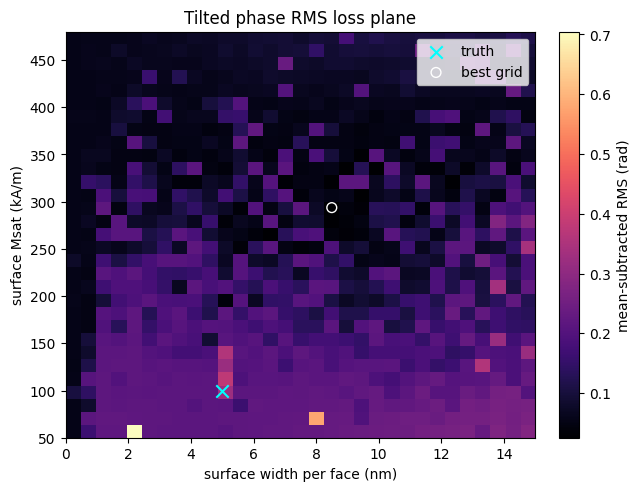

In [10]:
fig, ax = plt.subplots(figsize=(6.3, 4.8), constrained_layout=True)
extent = [width_grid_nm[0], width_grid_nm[-1], msat_grid_a_per_m[0] / 1e3, msat_grid_a_per_m[-1] / 1e3]
im = ax.imshow(loss_grid, origin="lower", aspect="auto", extent=extent, cmap="magma")
ax.scatter([truth_surface_width_nm], [truth_surface_msat_a_per_m / 1e3], marker="x", s=80, color="cyan", label="truth")
ax.scatter([best_grid_width_nm], [best_grid_msat_a_per_m / 1e3], marker="o", s=50, facecolors="none", edgecolors="white", label="best grid")
ax.set_xlabel("surface width per face (nm)")
ax.set_ylabel("surface Msat (kA/m)")
ax.set_title("Tilted phase RMS loss plane")
ax.legend(loc="best")
fig.colorbar(im, ax=ax, label="mean-subtracted RMS (rad)")
plt.show()


## Adam Refinement


In [11]:
theta0 = jnp.asarray(
    [
        inverse_bounded_value(best_grid_width_nm, width_bounds_nm),
        inverse_bounded_value(best_grid_msat_a_per_m, surface_msat_bounds_a_per_m),
    ],
    dtype=solver_dtype,
)


def host_dict(values):
    return {key: jax.device_get(value) for key, value in values.items()}


def run_adam(theta, *, steps=outer_steps, learning_rate=outer_learning_rate, log_every=adam_log_every):
    opt = optax.adam(learning_rate)
    opt_state = opt.init(theta)
    history = []

    started = time.perf_counter()
    (warmup_loss, _), _ = loss_grad_aux(theta)
    jax.block_until_ready(warmup_loss)
    compile_elapsed_s = time.perf_counter() - started

    started = time.perf_counter()
    for step in range(int(steps)):
        (loss, aux), grad = loss_grad_aux(theta)
        updates, opt_state = opt.update(grad, opt_state, theta)
        theta = optax.apply_updates(theta, updates)
        aux = host_dict(aux)
        row = {
            "step": step,
            "loss": float(jax.device_get(loss)),
            "width_nm": float(aux["width_nm"]),
            "surface_msat_a_per_m": float(aux["surface_msat_a_per_m"]),
            "elapsed_s": time.perf_counter() - started,
        }
        history.append(row)
        if step == 0 or (step + 1) % int(log_every) == 0 or step + 1 == int(steps):
            print(
                f"{step + 1:4d}/{steps}: RMS={row['loss']:.6g} rad | "
                f"width={row['width_nm']:.4g} nm | Ms={row['surface_msat_a_per_m'] / 1e3:.4g} kA/m"
            )

    final_loss, final_aux = loss_with_aux_jit(theta)
    final_aux = host_dict(final_aux)
    return {
        "theta": theta,
        "loss": float(jax.device_get(final_loss)),
        "width_nm": float(final_aux["width_nm"]),
        "surface_msat_a_per_m": float(final_aux["surface_msat_a_per_m"]),
        "phase_crop": np.asarray(final_aux["phase_crop"], dtype=np.float64),
        "m_cell_final": np.asarray(final_aux["m_final_cell"], dtype=np.float64),
        "history": history,
        "compile_elapsed_s": compile_elapsed_s,
        "optimizer_elapsed_s": history[-1]["elapsed_s"] if history else 0.0,
    }


fit_result = run_adam(theta0)
print(
    f"Final fixed-step fit: width={fit_result['width_nm']:.4g} nm, "
    f"surface Ms={fit_result['surface_msat_a_per_m'] / 1e3:.4g} kA/m, "
    f"RMS={fit_result['loss']:.6g} rad"
)
print(f"Compile: {fit_result['compile_elapsed_s']:.2f} s, optimize: {fit_result['optimizer_elapsed_s']:.2f} s")


   1/300: RMS=0.109192 rad | width=8.5 nm | Ms=293.7 kA/m
  10/300: RMS=0.0258931 rad | width=7.593 nm | Ms=278.3 kA/m
  20/300: RMS=0.0322277 rad | width=8.186 nm | Ms=295.2 kA/m
  30/300: RMS=0.0494884 rad | width=8.41 nm | Ms=301.5 kA/m
  40/300: RMS=0.149784 rad | width=8.497 nm | Ms=304 kA/m
  50/300: RMS=0.0516373 rad | width=8.531 nm | Ms=304.9 kA/m
  60/300: RMS=0.120995 rad | width=8.543 nm | Ms=305.3 kA/m
  70/300: RMS=0.070755 rad | width=8.547 nm | Ms=305.5 kA/m
  80/300: RMS=0.215228 rad | width=8.549 nm | Ms=305.5 kA/m
  90/300: RMS=0.030906 rad | width=8.55 nm | Ms=305.6 kA/m
 100/300: RMS=0.0513101 rad | width=8.55 nm | Ms=305.6 kA/m
 110/300: RMS=0.15673 rad | width=8.55 nm | Ms=305.6 kA/m
 120/300: RMS=0.0677487 rad | width=8.61 nm | Ms=304.8 kA/m
 130/300: RMS=0.091116 rad | width=8.965 nm | Ms=300 kA/m
 140/300: RMS=0.0704976 rad | width=9.093 nm | Ms=298.3 kA/m
 150/300: RMS=0.214175 rad | width=9.139 nm | Ms=297.7 kA/m
 160/300: RMS=0.08373 rad | width=9.155 nm | 

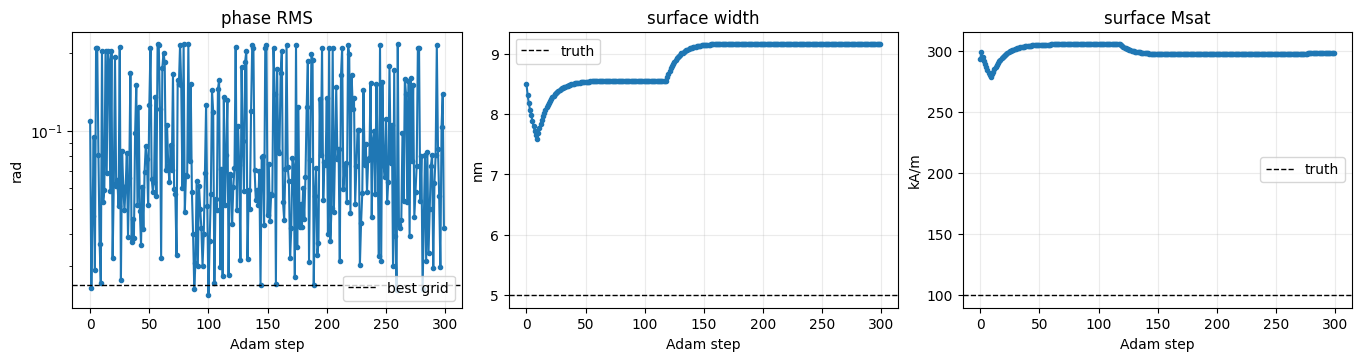

In [12]:
history = fit_result["history"]
steps = np.array([row["step"] for row in history], dtype=np.int64)
rms = np.array([row["loss"] for row in history], dtype=np.float64)
width_hist = np.array([row["width_nm"] for row in history], dtype=np.float64)
msat_hist = np.array([row["surface_msat_a_per_m"] for row in history], dtype=np.float64)

fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.5), constrained_layout=True)
axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o", ms=3)
axs[0].axhline(best_grid_loss, color="k", lw=1.0, ls="--", label="best grid")
axs[0].set_title("phase RMS")
axs[0].set_xlabel("Adam step")
axs[0].set_ylabel("rad")
axs[0].grid(True, alpha=0.25)
axs[0].legend()

axs[1].plot(steps, width_hist, marker="o", ms=3)
axs[1].axhline(truth_surface_width_nm, color="k", lw=1.0, ls="--", label="truth")
axs[1].set_title("surface width")
axs[1].set_xlabel("Adam step")
axs[1].set_ylabel("nm")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

axs[2].plot(steps, msat_hist / 1e3, marker="o", ms=3)
axs[2].axhline(truth_surface_msat_a_per_m / 1e3, color="k", lw=1.0, ls="--", label="truth")
axs[2].set_title("surface Msat")
axs[2].set_xlabel("Adam step")
axs[2].set_ylabel("kA/m")
axs[2].grid(True, alpha=0.25)
axs[2].legend()
plt.show()


## Final Dynamic Diagnostic


In [13]:
final_ms_field, final_kc_field = fit_material_fields(
    fit_result["width_nm"],
    fit_result["surface_msat_a_per_m"],
)
final_m_node, final_info = fit_minimizer.solve(
    input_m_node,
    final_ms_field,
    final_kc_field,
    tol=fit_inner_tol,
    max_iter=fit_dynamic_max_iter,
    return_info=True,
)
final_m_cell_dynamic = np.asarray(jax.device_get(cell_from_node_jax(final_m_node)), dtype=np.float64)
final_phase_yx = np.asarray(jax.device_get(phase_from_cell_jax(
    jnp.asarray(final_m_cell_dynamic, dtype=solver_dtype),
    final_ms_field
)), dtype=np.float64)
final_phase_crop = final_phase_yx[target_crop_y, target_crop_x]
final_dynamic_rms = float(np.asarray(jax.device_get(mean_subtracted_rms(
    jnp.asarray(final_phase_crop, dtype=solver_dtype),
    target_phase_crop_jax,
))))

print(f"Dynamic final n_iter: {int(np.asarray(final_info['n_iter'])):,}")
print(f"Dynamic final converged: {bool(np.asarray(final_info['converged']))}")
print(f"Dynamic final max_g: {float(np.asarray(final_info['max_g'])):.3g}")
print(f"Dynamic final RMS: {final_dynamic_rms:.6g} rad")
print(f"Recovered width error: {fit_result['width_nm'] - truth_surface_width_nm:+.4g} nm")
print(f"Recovered Msat error: {(fit_result['surface_msat_a_per_m'] - truth_surface_msat_a_per_m) / 1e3:+.4g} kA/m")


Dynamic final n_iter: 3,107
Dynamic final converged: True
Dynamic final max_g: 99.3
Dynamic final RMS: 0.0287525 rad
Recovered width error: +4.155 nm
Recovered Msat error: +198.3 kA/m


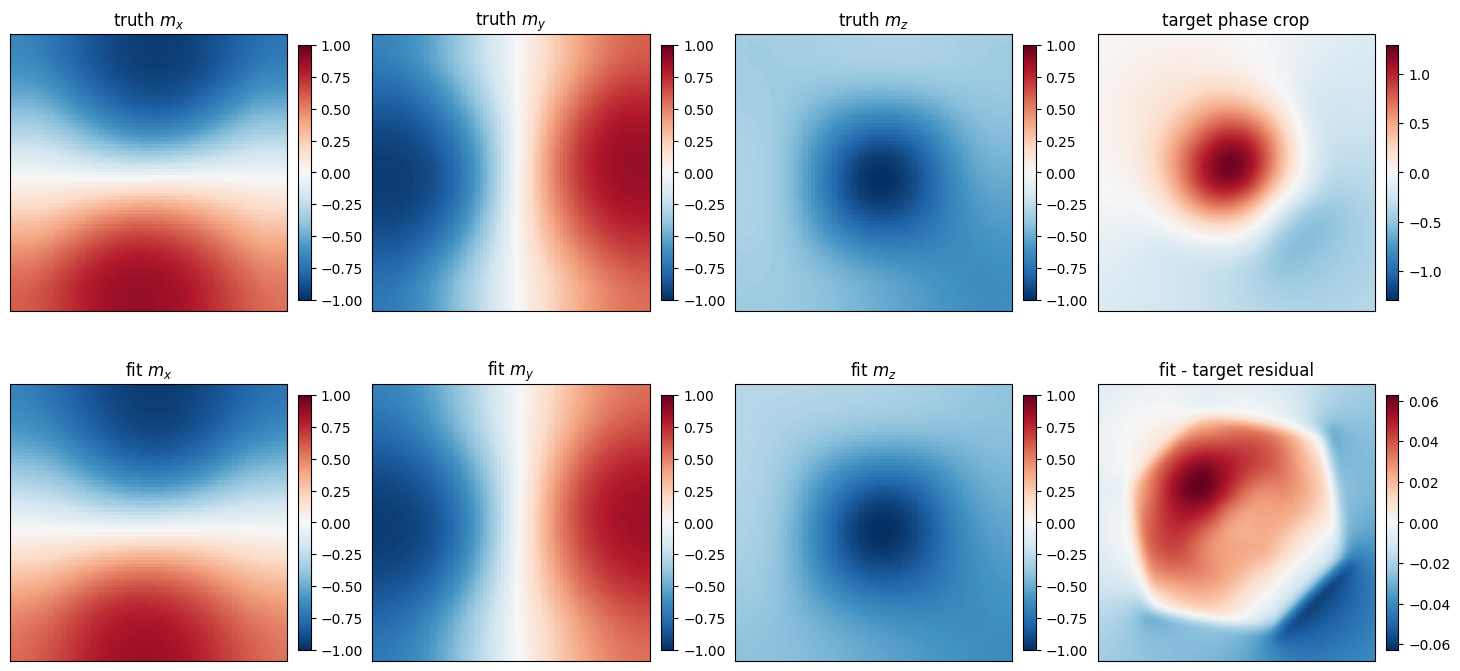

In [14]:
target_crop_centered = target_phase_crop - target_phase_crop.mean()
final_crop_centered = final_phase_crop - final_phase_crop.mean()
residual_crop = final_crop_centered - target_crop_centered
phase_lim = max(np.max(np.abs(target_crop_centered)), np.max(np.abs(final_crop_centered)), 1e-12)
resid_lim = max(np.max(np.abs(residual_crop)), 1e-12)

fig, axs = plt.subplots(2, 4, figsize=(14.5, 7.0), constrained_layout=True)
mid = n // 2
for ax, image, title in [
    (axs[0, 0], truth_m_cell[:, :, mid, 0].T, "truth $m_x$"),
    (axs[0, 1], truth_m_cell[:, :, mid, 1].T, "truth $m_y$"),
    (axs[0, 2], truth_m_cell[:, :, mid, 2].T, "truth $m_z$"),
    (axs[1, 0], final_m_cell_dynamic[:, :, mid, 0].T, "fit $m_x$"),
    (axs[1, 1], final_m_cell_dynamic[:, :, mid, 1].T, "fit $m_y$"),
    (axs[1, 2], final_m_cell_dynamic[:, :, mid, 2].T, "fit $m_z$"),
]:
    im = ax.imshow(image, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

im = axs[0, 3].imshow(target_crop_centered, cmap="RdBu_r", vmin=-phase_lim, vmax=phase_lim)
axs[0, 3].set_title("target phase crop")
axs[0, 3].set_xticks([])
axs[0, 3].set_yticks([])
fig.colorbar(im, ax=axs[0, 3], fraction=0.046, pad=0.04)

im = axs[1, 3].imshow(residual_crop, cmap="RdBu_r", vmin=-resid_lim, vmax=resid_lim)
axs[1, 3].set_title("fit - target residual")
axs[1, 3].set_xticks([])
axs[1, 3].set_yticks([])
fig.colorbar(im, ax=axs[1, 3], fraction=0.046, pad=0.04)
plt.show()
